# Graded Assignment: Regression Models

Kuis ini merupakan bagian dari proses penilaian Algoritma Training. Kami akan melakukan penilaian berupa kuis untuk menguji praktek teknik pembuatan model regresi yang sudah Anda pelajari.

## Pemahaman Metode

Regresi merupakan bagian dari supervised machine learning yang memiliki tujuan untuk memprediksi target variabel bertipe numerik. Metode dalam membangun model regresi bermacam-macam, salah satunya adalah regresi linear. Hal yang perlu diperhatikan sebelum membuat regresi linear adalah memastikan hubungan antar variabel target dengan variabel prediktor.

1. Di bawah ini, manakah kasus yang dapat diselesaikan menggunakan model regresi?

- [ ] Prediksi karyawan yang akan mengundurkan diri atau tidak.
- [ ] Deteksi transaksi fraud pada suatu online shop.
- [ ] Prediksi sentimen pelanggan terhadap suatu produk.
- [ ] Penentuan harga properti pada suatu kompleks.

## Volve Field Gas Production Analysis

Pada quiz berikut, Anda akan diminta membuat model regresi sebagai penilaian pemahaman mengenai materi yang sudah dipelajari sebelumnya. Kasus yang ingin diselesaikan adalah melakukan prediksi besar produksi gas bumi pada Volve Field berdasarkan informasi mesin yang digunakan.

### Import Data

Anda akan menggunakan data `volve_field_gas.csv` yang tersimpan pada folder `data_input`

In [1]:
import pandas as pd
# suppress scientific notation
pd.set_option('display.float_format', lambda x: '%.4f' % x) # pandas output

# read data
volve = pd.read_csv('data_input/volve_field_gas.csv')
volve.head()

,DATE_PERIOD,NPD_WELL_BORE_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,BORE_GAS_VOL
0,2008-03-21,15/9-F-12,24.0000,274.0720,105.9160,174.4980,6.6960,32.0872,99.5740,75.3560,458447.0000
1,2008-03-22,15/9-F-12,24.0000,273.4560,105.9150,174.2840,6.4620,32.0784,99.1720,75.3190,458028.0000
2,2008-03-23,15/9-F-12,24.0000,272.8810,105.9130,174.0880,6.2880,32.0607,98.7930,75.3530,466335.0000
3,2008-03-24,15/9-F-12,24.0000,272.2370,105.9130,173.8350,4.9570,32.1284,98.4020,74.8120,468480.0000
4,2008-03-25,15/9-F-12,24.0000,271.6840,105.9100,173.6440,14.9060,32.0421,98.0390,74.9590,406562.0000


Deskripsi data:

- `DATE_PERIOD`: Tanggal data produksi.
- `NPD_WELL_BORE_NAME`: Nama lubang sumur.
- `ON_STREAM_HRS`: Durasi sumur aktif berproduksi selama tanggal laporan.
- `AVG_DOWNHOLE_PRESSURE`: Tekanan rata-rata (bar) di dalam lubang sumur di bawah lubang.
- `AVG_DOWNHOLE_TEMPERATURE`: Suhu rata-rata (°C) di dalam lubang sumur di bawah lubang.
- `AVG_DP_TUBING`: Perbedaan tekanan rata-rata (bar) di seluruh pipa.
- `AVG_ANNULUS_PRESS`: Tekanan rata-rata (bar) di anulus (ruang antara casing dan pipa sumur). 
- `AVG_CHOKE_SIZE_P`: Rata-rata pengaturan ukuran katup choke (dalam persentase), yang mengendalikan aliran fluida dari sumur.
- `AVG_WHP_P`: Rata-rata pengaturan tekanan kepala sumur (dalam persentase), yang mengendalikan tekanan di permukaan kepala sumur.
- `AVG_WHT_P`: Rata-rata pengaturan suhu kepala sumur (dalam persentase), yang mengendalikan suhu di permukaan kepala sumur.
- `BORE_GAS_VOL`: Volume gas bumi (cubic feet) yang diproduksi.

Untuk memastikan Anda telah memuat data dengan benar, periksa apakah kolom telah disimpan dengan tipe data yang sesuai dan jika belum sesuai silakan lakukan adjust data types.

In [2]:
# cek tipe data
volve.dtypes

DATE_PERIOD                  object
NPD_WELL_BORE_NAME           object
ON_STREAM_HRS               float64
AVG_DOWNHOLE_PRESSURE       float64
AVG_DOWNHOLE_TEMPERATURE    float64
AVG_DP_TUBING               float64
AVG_ANNULUS_PRESS           float64
AVG_CHOKE_SIZE_P            float64
AVG_WHP_P                   float64
AVG_WHT_P                   float64
BORE_GAS_VOL                float64
dtype: object

In [5]:
# your code here
print(volve.isnull().sum())
# adjust data types
volve['DATE_PERIOD'] = pd.to_datetime(volve['DATE_PERIOD'])
volve['NPD_WELL_BORE_NAME'] = volve['NPD_WELL_BORE_NAME'].astype('category')


DATE_PERIOD                 0
NPD_WELL_BORE_NAME          0
ON_STREAM_HRS               0
AVG_DOWNHOLE_PRESSURE       0
AVG_DOWNHOLE_TEMPERATURE    0
AVG_DP_TUBING               0
AVG_ANNULUS_PRESS           0
AVG_CHOKE_SIZE_P            0
AVG_WHP_P                   0
AVG_WHT_P                   0
BORE_GAS_VOL                0
dtype: int64


### Exporatory Data Analysis

Untuk memilih variabel prediktor biasanya kita menggunakan korelasi. Dengan melihat korelasi, kita dapat mengetahui variabel mana yang memiliki hubungan kuat dengan produksi gas bumi.

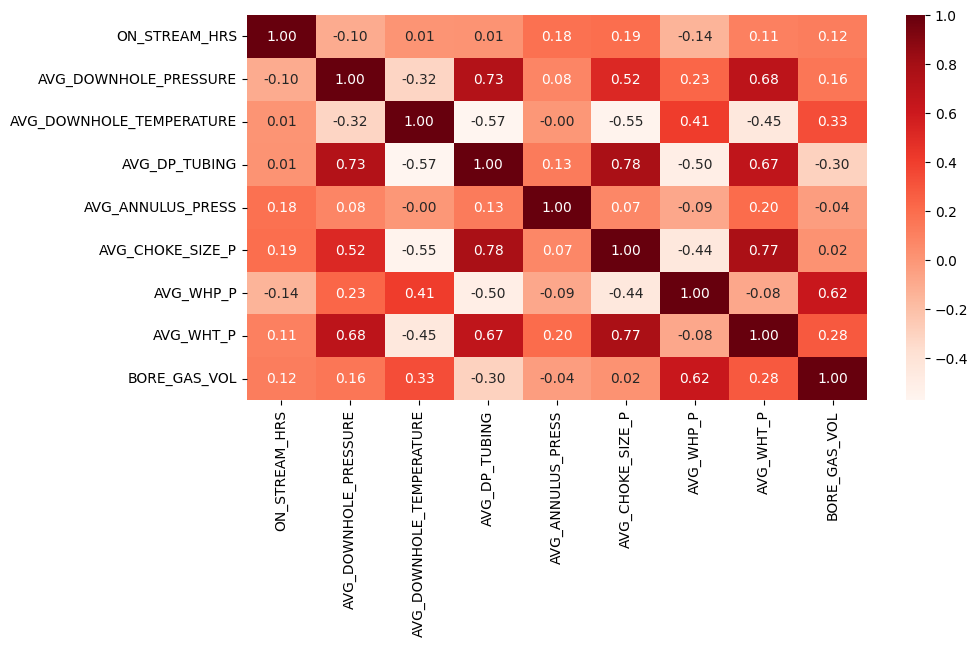

In [7]:
# your code here
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize = (10,5))

fig = sns.heatmap(volve.corr(numeric_only=True), # nilai korelasi
                  annot=True,   # anotasi angka di dalam kotak heatmap
                  fmt=".2f",    # format 3 angka dibelakang koma 
                  cmap='Reds'); # warna heatmap
# correlation


2.  Variabel mana di bawah ini yang memiliki korelasi paling kuat dengan variabel `BORE_GAS_VOL` sehingga diperkirakan cocok sebagai variabel prediktor?

- [ ] `AVG_ANNULUS_PRESS`
- [ ] `ON_STREAM_HRS`
- [ ] `AVG_WHP_P`
- [ ] `BORE_GAS_VOL`

### Data Preprocessing

Variabel prediktor untuk memprediksi produksi gas bumi bertipe data numerik dan kategorik, maka dari itu harus dilakukan data encoding terlebih dahulu untuk tipe data kategorik menjadi dummy variable.

In [10]:
# code here
y = volve['BORE_GAS_VOL']
x = volve.drop(columns=['BORE_GAS_VOL','DATE_PERIOD','AVG_DP_TUBING'],axis=1)
x = pd.get_dummies(data=x,columns=['NPD_WELL_BORE_NAME'], drop_first=True)
x


,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,NPD_WELL_BORE_NAME_15/9-F-12,NPD_WELL_BORE_NAME_15/9-F-14,NPD_WELL_BORE_NAME_15/9-F-15
0,24.0000,274.0720,105.9160,6.6960,32.0872,99.5740,75.3560,True,False,False
1,24.0000,273.4560,105.9150,6.4620,32.0784,99.1720,75.3190,True,False,False
2,24.0000,272.8810,105.9130,6.2880,32.0607,98.7930,75.3530,True,False,False
3,24.0000,272.2370,105.9130,4.9570,32.1284,98.4020,74.8120,True,False,False
4,24.0000,271.6840,105.9100,14.9060,32.0421,98.0390,74.9590,True,False,False
...,...,...,...,...,...,...,...,...,...,...
4103,24.0000,253.3990,105.2670,22.5640,100.0000,26.9990,83.8210,False,False,False
4104,24.0000,253.2100,105.2720,22.7200,100.0000,26.9550,84.7800,False,False,False
4105,24.0000,252.9390,105.2740,22.5810,100.0000,26.9020,82.5890,False,False,False
4106,24.0000,252.8920,105.2760,22.5710,100.0000,26.8700,83.6080,False,False,False


### Model Fitting

Mari kita coba membuat model linier regresi menggunakan seluruh informasi variabel prediktor yang tersedia pada dataset `volve` kecuali `DATE_PERIOD` dan `AVG_DP_TUBING`, kemudian simpan model tersebut pada variabel `model_ols`.

In [21]:
import numpy as np
import statsmodels.api as sm

# Mendefinisikan variabel target & prediktor
Y = y  # variabel dependen (target)
X = sm.add_constant(x)  # menambahkan kolom 1 untuk intercept (β₀)
X = X.astype(float)
# Fit (melatih) model dengan data
model_ols = sm.OLS(Y, X).fit()

Untuk menganalisis bagaimana pengaruh tiap prediktor terhadap produksi gas bumi, tampilkan intercept dan koefisien yang dihasilkan model `model_ols`.

In [22]:
# your code here
# Menampilkan intercept & koefisien slope
print(model_ols.params)


const                             512.5959
ON_STREAM_HRS                    6306.9416
AVG_DOWNHOLE_PRESSURE           -3583.2791
AVG_DOWNHOLE_TEMPERATURE         4442.5509
AVG_ANNULUS_PRESS               -1544.2902
AVG_CHOKE_SIZE_P                  627.5466
AVG_WHP_P                        3702.3664
AVG_WHT_P                        2790.3443
NPD_WELL_BORE_NAME_15/9-F-12   339751.0346
NPD_WELL_BORE_NAME_15/9-F-14    13209.0852
NPD_WELL_BORE_NAME_15/9-F-15   -62522.5627
dtype: float64


3. Dari pernyataan berikut, pilih pernyataan yang **SALAH** mengenai nilai koefisien dari model!

  - [ ] Jika volve menggunakan lubang sumur `15/9-F-15`, maka produksi gas bumi akan meningkat ± 62 ribu dibanding jika menggunakan lubang umur `15/9-F-11`
  - [ ] Koefisien `AVG_DOWNHOLE_PRESSURE` negatif, artinya jika `AVG_DOWNHOLE_PRESSURE` meningkat maka volume gas bumi menurun.
  - [ ] Koefisien `AVG_WHP_P` positif, artinya jika `AVG_WHP_P` meningkat maka volume gas bumi meningkat.
  - [ ] Ketika `ON_STREAM_HRS` naik 1 nilai, maka volume gas bumi akan meningkat ± 6 ribu dengan menganggap semua nilai variabel yang lain konstan.

Setelah membuat model, kita dapat mengevaluasi bagaimana performa model yang telah terbentuk terhadap data `Y` dan `X`. Silahkan hitung besar R-Squared dan Root Mean Squared Error dari hasil prediksi model.

In [23]:
# your code here
# Prediksi
model_ols.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           BORE_GAS_VOL   R-squared:                       0.875
Model:                            OLS   Adj. R-squared:                  0.875
Method:                 Least Squares   F-statistic:                     2878.
Date:                Fri, 17 Oct 2025   Prob (F-statistic):               0.00
Time:                        21:05:19   Log-Likelihood:                -51842.
No. Observations:                4108   AIC:                         1.037e+05
Df Residuals:                    4097   BIC:                         1.038e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                          512.5959   6.01e+04      0.009      0.993   -1.17e+05    1.18e+05
ON_STREAM_HRS                 6306.9416    406.000     15.534      0.000    5510.961    7102.922
AVG_DOWNHOLE_PRESSURE        -3583.2791     83.712    -42.805      0.000   -3747.400   -3419.158
AVG_DOWNHOLE_TEMPERATURE      4442.5509    528.273      8.410      0.000    3406.848    5478.253
AVG_ANNULUS_PRESS            -1544.2902    247.410     -6.242      0.000   -2029.348   -1059.233
AVG_CHOKE_SIZE_P               627.5466     71.372      8.793      0.000     487.619     767.474
AVG_WHP_P                     3702.3664    164.903     22.452      0.000    3379.067    4025.666
AVG_WHT_P                     2790.3443    257.434     10.839      0.000    2285.635    3295.054
NPD_WELL_BORE_NAME_15/9-F-12  3.398e+05   6064.368     56.024      0.000    3.28e+05    3.52e+05
NPD_WELL_BORE_NAME_15/9-F-14  1.321e+04   5707.846      2.314      0.021    2018.608    2.44e+04
NPD_WELL_BORE_NAME_15/9-F-15 -6.252e+04   1.14e+04     -5.500      0.000   -8.48e+04   -4.02e+04
==============================================================================
Omnibus:                      468.637   Durbin-Watson:                   0.499
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4237.971
Skew:                          -0.140   Prob(JB):                         0.00
Kurtosis:                       7.968   Cond. No.                     1.50e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.5e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
# your code here
# R-Squared


In [25]:
# your code here
# RMSE
y_pred = model_ols.predict(X)
rmse = np.sqrt(np.mean((Y - y_pred) ** 2))
print("RMSE:", rmse)



RMSE: 73199.81949154212


4. Berdasarkan hasil evaluasi, pilih pernyataan yang **TEPAT** mengenai performa model regresi `model_ols`!

  - [ ] Semakin rendah nilai R-Squared, semakin baik performa model
  - [ ] Semakin tinggi nilai RMSE, semakin baik performa model
  - [ ] Nilai R-Squared dari hasil prediksi model adalah ± 87%
  - [ ] Nilai RMSE dari hasil prediksi model adalah ± 103 ribu.

## Assumption

5. Salah satu asumsi dari regresi linear yang harus dipenuhi adalah asumsi bahwa error yang dihasilkan berdistribusi normal. Salah satu uji statistik yang dapat digunakan untuk membuktikan normalitas dari residual adalah uji Shapiro. Manakah pernyataan yang sesuai dengan yang diharapkan dari uji Shapiro untuk model regresi linier?

  - [ ] P-value > Alpha, maka model kita tidak lulus uji normality residual.
  - [ ] P-value > Alpha, maka model kita lulus uji normality residual.
  - [ ] P-value < Alpha, maka model kita tidak lulus uji normality residual.
  - [ ] P-value < Alpha, maka model kita lulus uji normality residual.